In [50]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils import data
from torchvision import datasets,transforms, utils
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

# DCGAN

In [51]:
BATCH_SIZE=128
EPOCHS=100

In [40]:
train_ds=datasets.MNIST(root='./data/',
                     train=True,
                     download=False,
                     transform=transform)
tr_ds_loader=data.DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)

In [41]:
Z_DIM=3
IMG_C=1
IMG_SIZE=28

In [42]:
D=nn.Sequential(
    nn.Conv2d(IMG_C,64,4,2,1,bias=False), # [64,14,14]
    nn.LeakyReLU(0.2,inplace=True), 
    nn.Conv2d(64,128,4,2,1,bias=False), # [128,7,7]
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2,inplace=True),
    nn.Flatten(),
    nn.Linear(128*7*7,1),
    nn.Sigmoid()
)

In [43]:
G=nn.Sequential(
    nn.Linear(Z_DIM,128*7*7),
    nn.BatchNorm1d(128*7*7),
    nn.ReLU(),
    nn.Unflatten(1,(128,7,7)), # [128,7,7]
    nn.ConvTranspose2d(128,64,4,2,1,bias=False), # [64,14,14]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.ConvTranspose2d(64,IMG_C,4,2,1,bias=False), # [1,28,28]
    nn.Tanh()
)

In [44]:
G=G.to(DEVICE)
D=D.to(DEVICE)

criterion=nn.BCELoss()
d_opt=optim.Adam(D.parameters(),lr=0.0002)
g_opt=optim.Adam(G.parameters(),lr=0.0002)

0회 d_loss : 0.05710992217063904, g_loss : 3.9310808181762695, D(G(z)) : 0.0388348214328289, D(x) : 0.9835525751113892


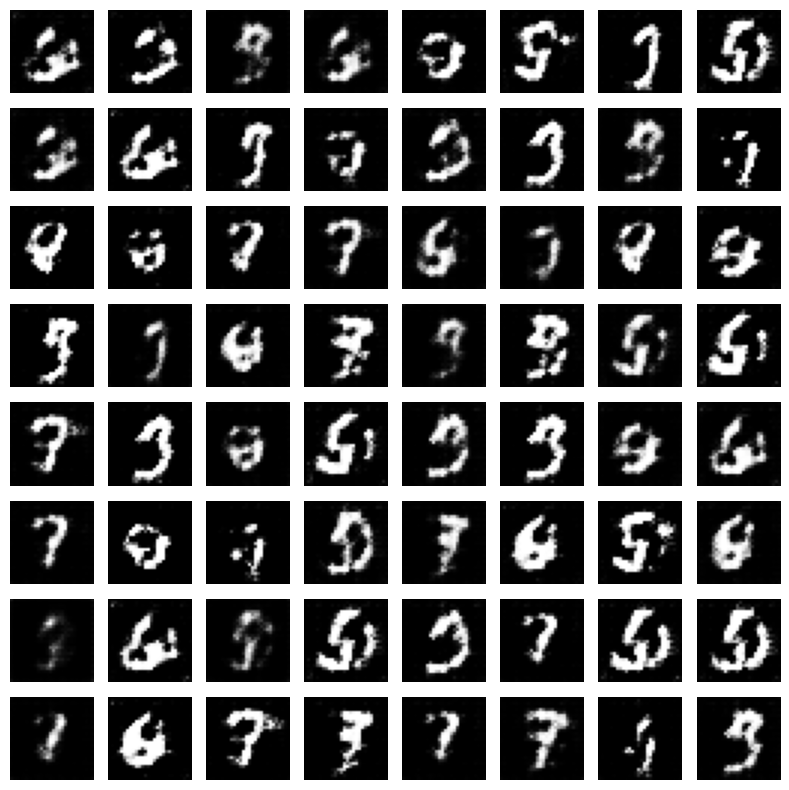

1회 d_loss : 0.05563164874911308, g_loss : 4.612184047698975, D(G(z)) : 0.035445742309093475, D(x) : 0.982848048210144


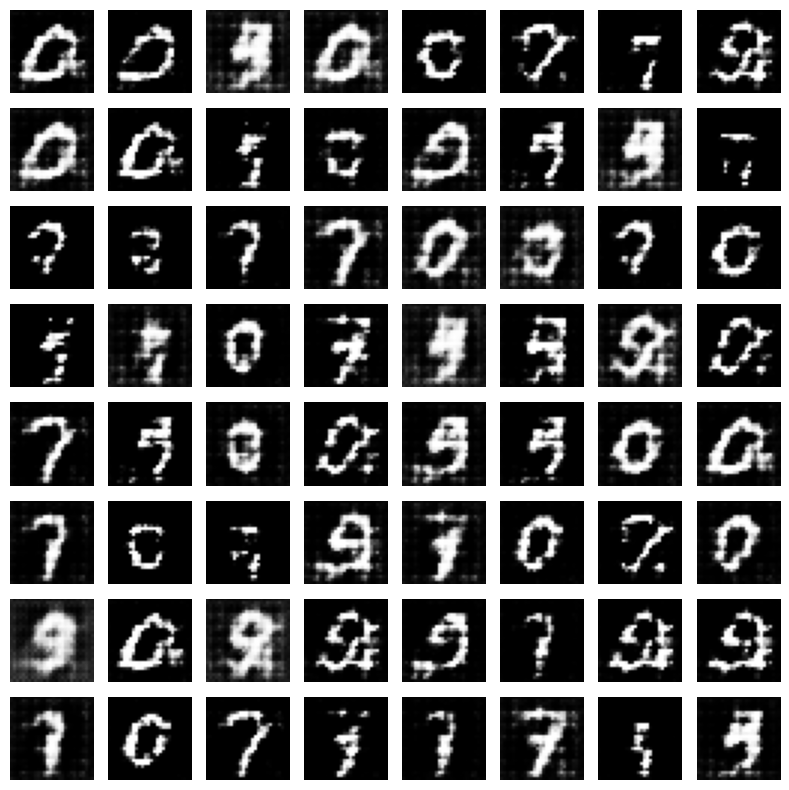

2회 d_loss : 0.027260441333055496, g_loss : 4.632099151611328, D(G(z)) : 0.01844092458486557, D(x) : 0.9917316436767578


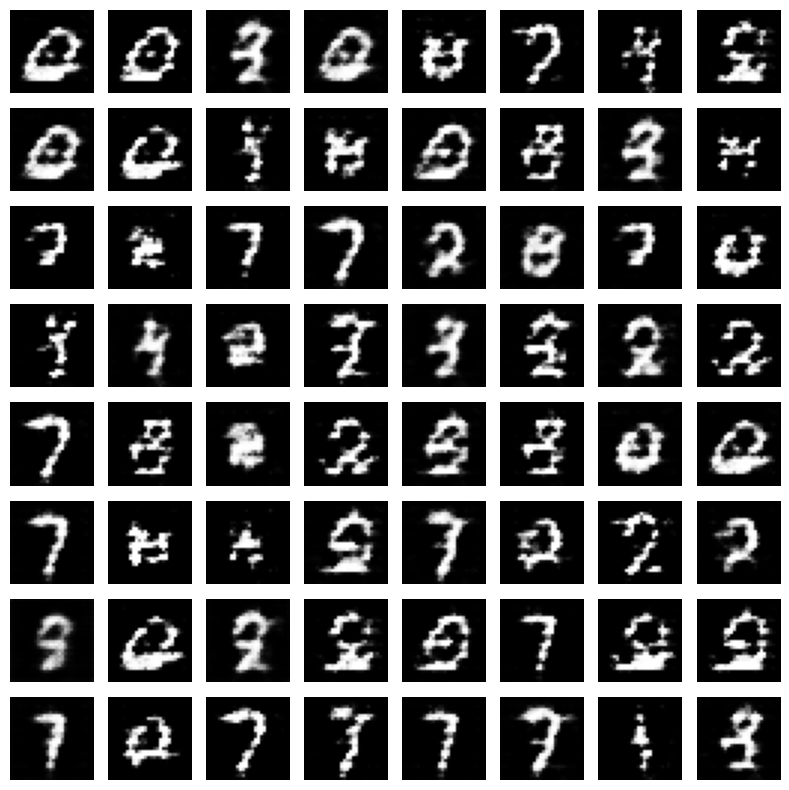

3회 d_loss : 0.04903847724199295, g_loss : 4.069644927978516, D(G(z)) : 0.025907058268785477, D(x) : 0.9796638488769531


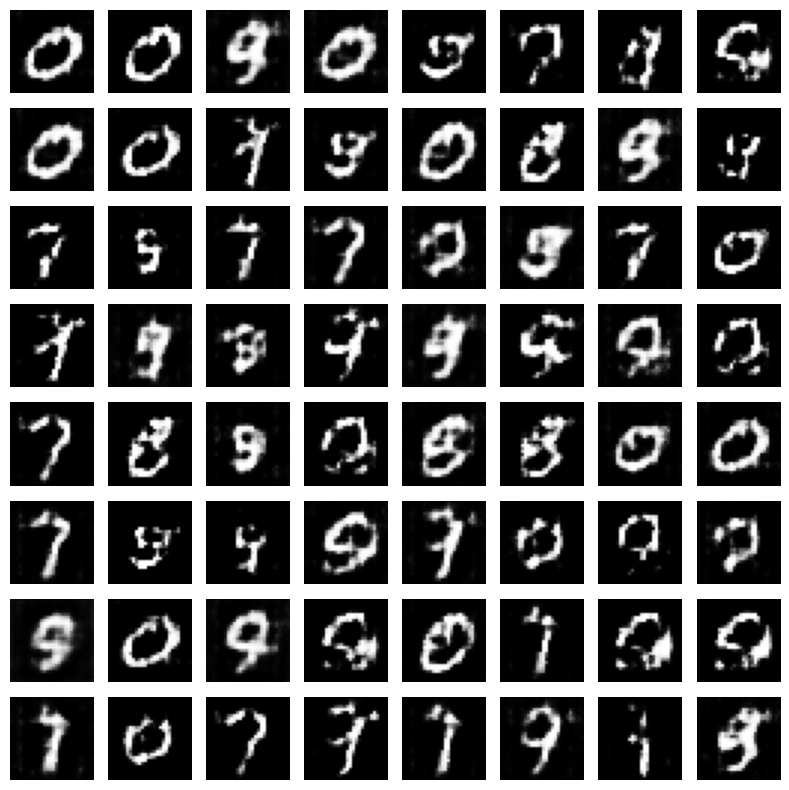

4회 d_loss : 0.06384219974279404, g_loss : 4.080837249755859, D(G(z)) : 0.04238934442400932, D(x) : 0.9832862019538879


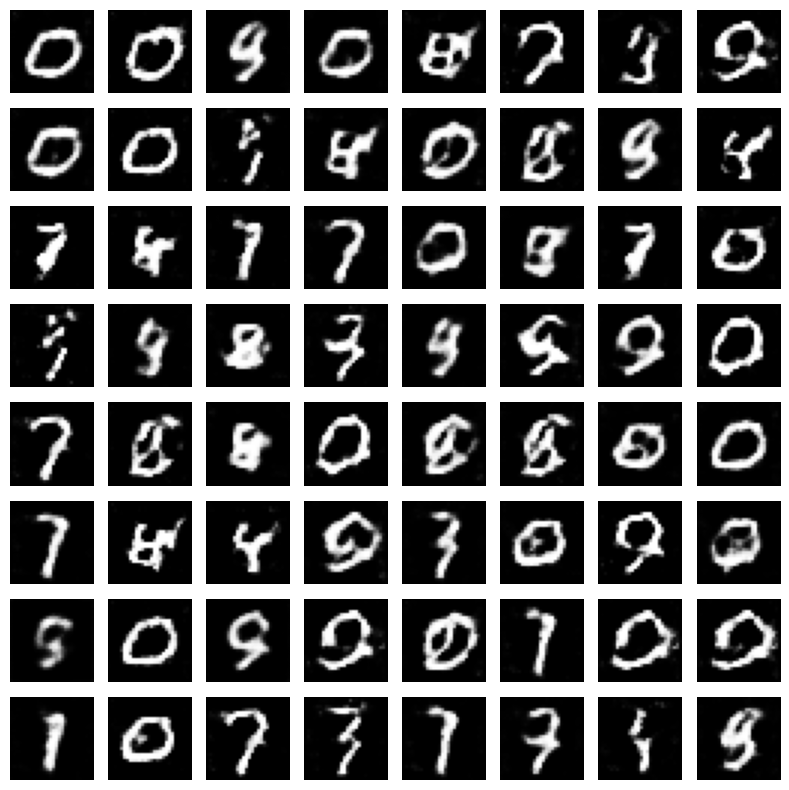

5회 d_loss : 0.0745576024055481, g_loss : 4.1070356369018555, D(G(z)) : 0.018450278788805008, D(x) : 0.9591521620750427


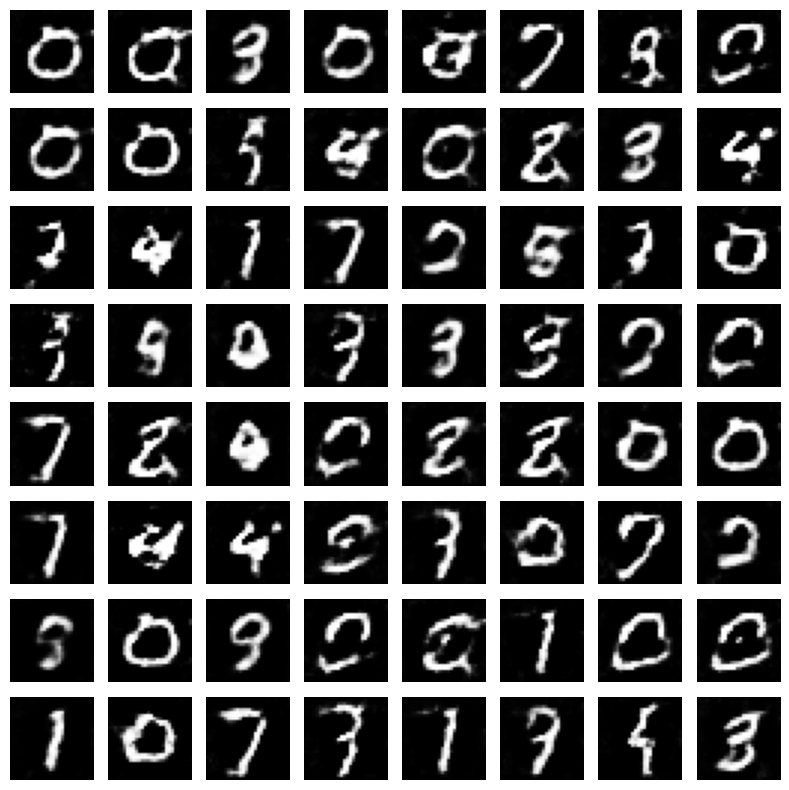

KeyboardInterrupt: 

In [47]:
z_noise=torch.randn(64,Z_DIM,device=DEVICE)
for epoch in range(EPOCHS):
    for i,(x,_) in enumerate(tr_ds_loader):
        data=x.to(DEVICE) # data.size(0)
        r_label=torch.ones(BATCH_SIZE,1,device=DEVICE)
        f_label=torch.zeros(BATCH_SIZE,1,device=DEVICE)

        z=torch.randn(BATCH_SIZE,Z_DIM,device=DEVICE)
        f_img=G(z)

        real_out=D(data)
        d_loss_real=criterion(real_out,r_label)
        real_sc=real_out.detach()
        
        fake_out=D(f_img.detach())
        d_loss_fake=criterion(fake_out,f_label)
        fake_sc=fake_out.detach()

        d_loss=d_loss_real+d_loss_fake

        g_opt.zero_grad()
        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        fake_out_ck_g=D(f_img)
        g_loss=criterion(fake_out_ck_g,r_label)

        g_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    print(f'{epoch}회 d_loss : {d_loss.item()}, g_loss : {g_loss.item()}, D(G(z)) : {fake_sc.mean().item()}, D(x) : {real_sc.mean().item()}')
    with torch.no_grad():
        G.eval()
        v_img=G(z_noise) # (64,1,28,28)
        v_img=(v_img+1)/2

        f,a=plt.subplots(8,8,figsize=(8,8))
        for i,ax in enumerate(a.flat):
            img=v_img[i].cpu().permute(1,2,0).numpy()
            ax.imshow(img.squeeze(),cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.show()
        G.train()

# fashion MNIST 데이터 이용 DCGAN 구현

0회 d_loss:0.0273982472717762 g_loss:4.984471797943115 D(G(z)):0.011056940071284771 D(x):0.9860274791717529


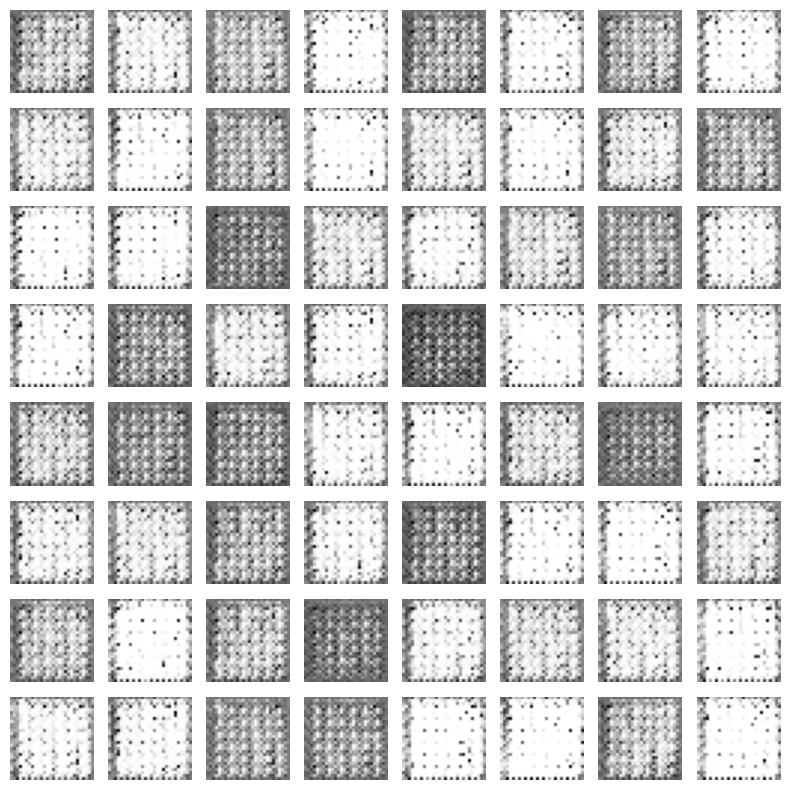

1회 d_loss:0.049176037311553955 g_loss:4.424577713012695 D(G(z)):0.0226144902408123 D(x):0.9753442406654358


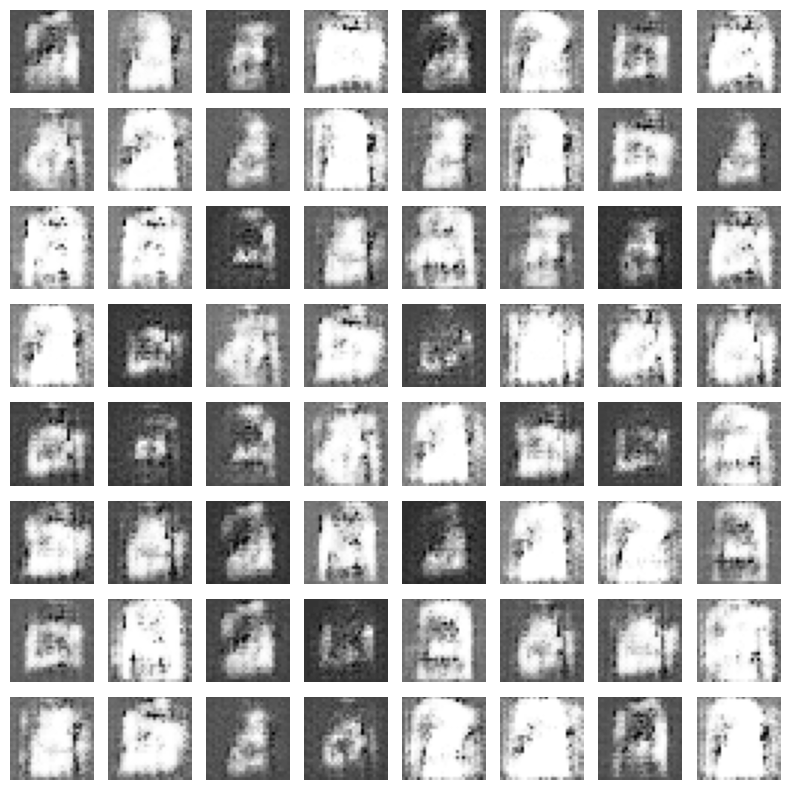

2회 d_loss:0.04034361615777016 g_loss:4.204247951507568 D(G(z)):0.028975944966077805 D(x):0.9897860884666443


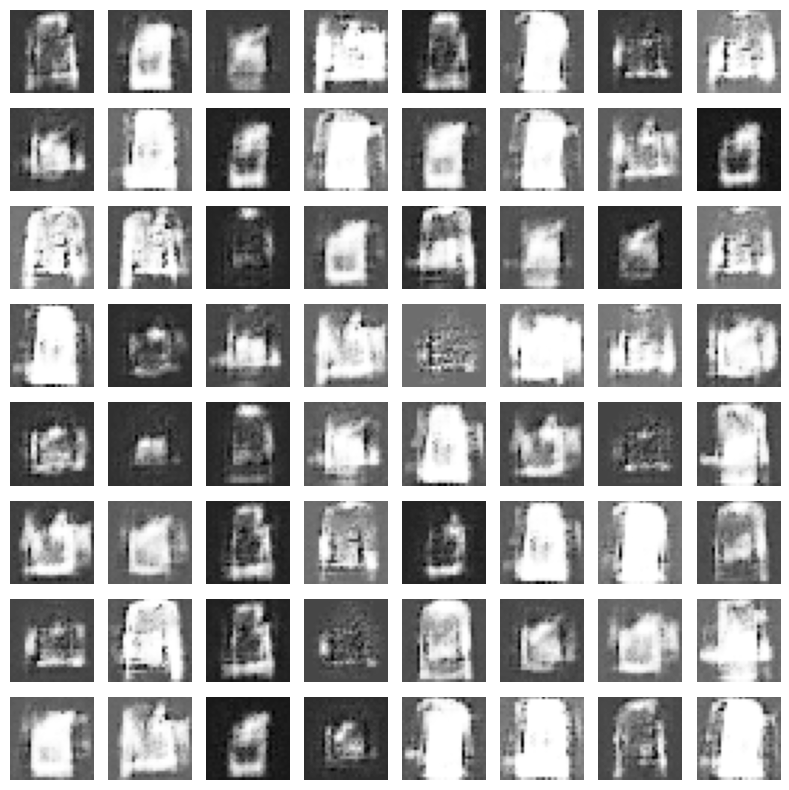

3회 d_loss:0.05218596011400223 g_loss:4.112192630767822 D(G(z)):0.0243336483836174 D(x):0.9772710204124451


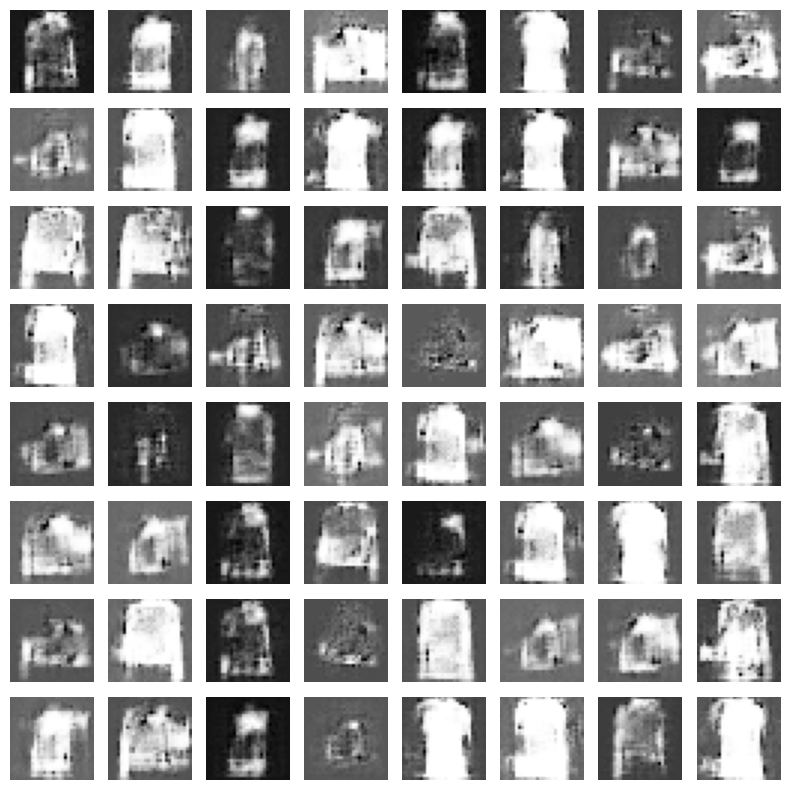

4회 d_loss:0.0655023455619812 g_loss:4.692331790924072 D(G(z)):0.011801518499851227 D(x):0.9611475467681885


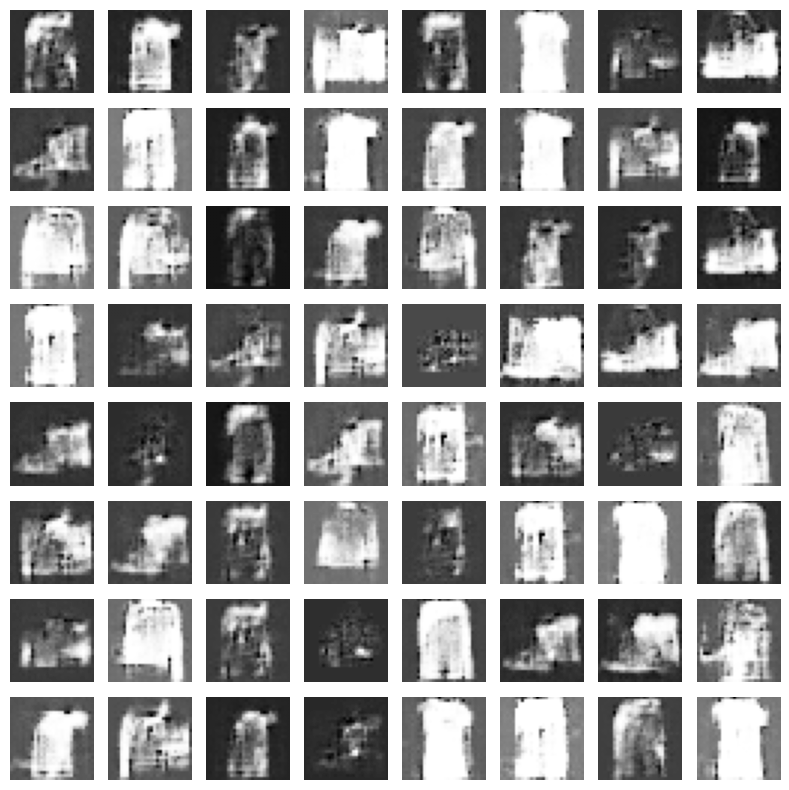

5회 d_loss:0.03837563470005989 g_loss:4.300320625305176 D(G(z)):0.03221067413687706 D(x):0.9949824213981628


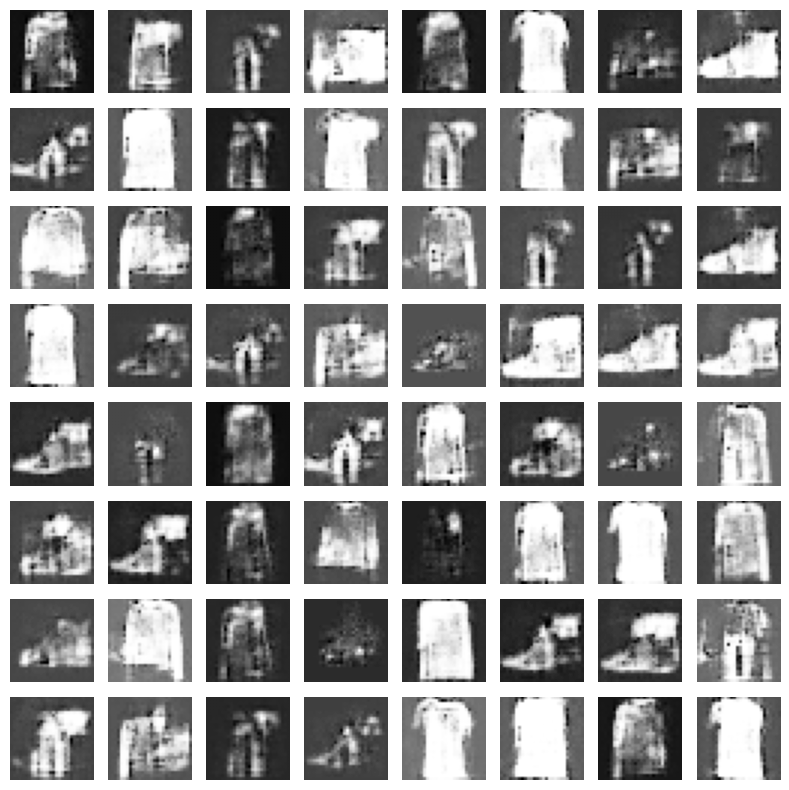

KeyboardInterrupt: 

In [52]:
BATCH_SIZE=128
EPOCHS=100

Z_DIM=3
IMG_C=1
IMG_SIZE=28

tr_ds=datasets.FashionMNIST(root='./data/',
                     train=True,
                     download=False,
                     transform=transforms.Compose([transforms.ToTensor()]))
tr_ds_loader = data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,drop_last=True)


D=nn.Sequential(
    nn.Conv2d(IMG_C,64,4,2,1,bias=False), # [64,14,14]
    nn.LeakyReLU(0.2,inplace=True),
    nn.Conv2d(64,128,4,2,1,bias=False), # [128,7,7]
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2,inplace=True),
    nn.Flatten(),
    nn.Linear(128*7*7,1),
    nn.Sigmoid()
)

G=nn.Sequential(
    nn.Linear(Z_DIM,128*7*7),
    nn.BatchNorm1d(128*7*7),
    nn.ReLU(),
    nn.Unflatten(1,(128,7,7)), # [128,7,7]
    nn.ConvTranspose2d(128,64,4,2,1,bias=False), # [64,14,14]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.ConvTranspose2d(64,IMG_C,4,2,1,bias=False), # [1,28,28]
    nn.Tanh()
)

G=G.to(DEVICE)
D=D.to(DEVICE)

criterion=nn.BCELoss()
d_opt=optim.Adam(D.parameters(),lr=0.0002)
g_opt=optim.Adam(G.parameters(),lr=0.0002)

z_noise=torch.randn(64,Z_DIM,device=DEVICE)
for epoch in range(EPOCHS):
    for i,(x,_) in enumerate(tr_ds_loader):
        data=x.to(DEVICE)
        #data.size(0)
        r_label=torch.ones(BATCH_SIZE,1,device=DEVICE)
        f_label=torch.zeros(BATCH_SIZE,1,device=DEVICE)

        z=torch.randn(BATCH_SIZE,Z_DIM,device=DEVICE)
        f_img=G(z)

        real_out=D(data)
        d_loss_real=criterion(real_out,r_label)
        real_sc=real_out.detach()

        fake_out=D(f_img.detach())
        d_loss_fake=criterion(fake_out,f_label)
        fake_sc=fake_out.detach()

        d_loss=d_loss_real+d_loss_fake

        g_opt.zero_grad()
        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        fake_out_ck_g=D(f_img)
        g_loss=criterion(fake_out_ck_g,r_label)

        g_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        g_opt.step()
    print(f'{epoch}회 d_loss:{d_loss.item()} g_loss:{g_loss.item()} D(G(z)):{fake_sc.mean().item()} D(x):{real_sc.mean().item()}')
    
    with torch.no_grad():
        G.eval()
        v_img=G(z_noise) # (64,1,28,28)
        v_img=(v_img+1)/2

        f,a=plt.subplots(8,8,figsize=(8,8))
        for i,ax in enumerate(a.flat):
            img=v_img[i].cpu().permute(1,2,0).numpy()
            ax.imshow(img.squeeze(),cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.show()
        G.train()   

In [55]:
import os
import shutil
import pathlib
base_dir=pathlib.Path('C:/Users/ksa/Desktop/vs/pn/deep/test/cats_vs_dogs_small') # 기준 경로를 만들어라
dir_test=pathlib.Path('C:/Users/ksa/Desktop/vs/pn/deep/test/cats_vs_dogs_small/test')
dir_train=pathlib.Path('C:/Users/ksa/Desktop/vs/pn/deep/test/cats_vs_dogs_small/train')


In [57]:
BATCH_SIZE=128
EPOCHS=100

In [66]:
from torch.utils.data import random_split

# train 데이터셋 전체
full_train_ds = datasets.ImageFolder(dir/'train', transform=transform)

# train : val 비율 설정 (예: 80% : 20%)
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size

# 데이터셋 분리
tr_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

# DataLoader 생성
tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [67]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

img_size = 128
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

# 전체 train 데이터셋
full_train_ds = datasets.ImageFolder(dir/'train', transform=transform)

# train/val split
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size
tr_ds, val_ds = random_split(full_train_ds, [train_size, val_size])

# DataLoader
tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# test 데이터
tt_ds = datasets.ImageFolder(dir/'test', transform=transform)
tt_ds_loader = DataLoader(tt_ds, batch_size=BATCH_SIZE, shuffle=False)

In [62]:
tr_ds.classes

['cat', 'dog']

In [68]:
x,y=next(iter(tr_ds_loader))

In [77]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms

class F_datasets(Dataset):
    cd=['cat','dog']
    def __init__(self,dir,transform=None):
        self.img_f = []
        for i in self.cd:
            self.img_dir=dir/i
            self.img_f=list(self.img_dir.glob('*.jpg'))
            if len(self.img_f)==0:
                print('로드할 파일 없음')
            self.transform=transform

    def __len__(self):
        return len(self.img_f)
    
    def __getitem__(self,idx):
        img_path=self.img_f[idx]
        
        image=Image.open(img_path).convert('RGB')
        # 내용 변경 파악
        label_name=img_path.stem.split('.')[0].lower() # cat.0.jpg
        if label_name=='cat':
            label=0
        elif label_name=='dog':
            label=1
        else:
            raise ValueError(f'파일 클래스 내용 없는 파일이 로드됨 -> {img_path.name}')
        
        if self.transform:
            image=self.transform(image)

        return image,label
    
file_path=pathlib.Path('C:/Users/ksa/Desktop/vs/pn/deep/test/cats_vs_dogs_small/train')
transform=transforms.Compose([
    transforms.Resize((100,100)),
    transforms.ToTensor()
])

tr_ds=F_datasets(file_path,transform)
tr_ds_loader=DataLoader(tr_ds,batch_size=4,shuffle=True)

In [ ]:
x,y=next(iter(tr_ds_loader))

In [80]:
# 모든 파일 한 폴더에 위치하지 않고 데이터 클래스별 분할 x 상황
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import transforms

class F_datasets(Dataset):
    cd=['cat','dog']
    def __init__(self,dir,transform=None):
        self.img_f = []
        for i in self.cd:
            self.img_dir=dir/i
            self.img_f=list(self.img_dir.glob('*.jpg'))
            if len(self.img_f)==0:
                print('로드할 파일 없음')
            self.transform=transform

    def __len__(self):
        return len(self.img_f)
    
    def __getitem__(self,idx):
        img_path=self.img_f[idx]
        
        image=Image.open(img_path).convert('RGB')
        # 내용 변경 파악
        label_name=img_path.stem.split('.')[0].lower() # cat.0.jpg
        if label_name=='cat':
            label=0
        elif label_name=='dog':
            label=1
        else:
            raise ValueError(f'파일 클래스 내용 없는 파일이 로드됨 -> {img_path.name}')
        
        if self.transform:
            image=self.transform(image)

        return image,label
    
file_path=pathlib.Path('C:/Users/ksa/Desktop/vs/pn/deep/test/cats_vs_dogs_small/train')
transform=transforms.Compose([
    transforms.Resize((100,100)),
    transforms.ToTensor()
])

all_ds=F_datasets(file_path,transform)
all_ds_n = len(all_ds)

# 비율: train 70%, test 20%, val 10%
tr_ds_n = int(all_ds_n * 0.7)
tt_ds_n = int(all_ds_n * 0.2)
val_ds_n = all_ds_n - tr_ds_n - tt_ds_n  # 남은 걸 val로

tr_ds, tt_ds, val_ds = random_split(all_ds, [tr_ds_n, tt_ds_n, val_ds_n])
tr_ds_n, tt_ds_n, val_ds_n


(700, 200, 100)

디렉토리 파일 로두 후 class 활용한 ANN,CNN 모델 구축 -> 모델 학습/추론
- 데이터 : dog-vs-cats
- 데이터 전부 활용
- 학습, 추론 함수로 정리

In [83]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim

class F_datasets(Dataset):
    classes = ['cat', 'dog']

    def __init__(self, dir, transform=None):
        self.img_f = []
        self.labels = []
        dir = Path(dir)

        for idx, cls in enumerate(self.classes):
            img_dir = dir / cls
            files = list(img_dir.glob('*.jpg'))
            if len(files) == 0:
                print(f'로드할 파일 없음: {cls}')
            self.img_f.extend(files)                # 이미지 경로 누적
            self.labels.extend([idx] * len(files))  # 라벨 누적
        self.transform = transform

    def __len__(self):
        return len(self.img_f)

    def __getitem__(self, idx):
        img_path = self.img_f[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_path = "C:/Users/ksa/Desktop/vs/pn/vision/dogs-vs-cats_data/tr_data"
test_path  = "C:/Users/ksa/Desktop/vs/pn/vision/dogs-vs-cats_data/tt_data"

train_ds = F_datasets(train_path, transform=transform)
test_ds  = F_datasets(test_path, transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128*128*3, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for Net in [DNN, CNN]:
    print(f"\n[{Net.__name__} 학습 시작]")
    model = Net().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(5):
        loss = train_model(model, train_loader, criterion, optimizer, device)
        acc = evaluate_model(model, test_loader, device)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, Test Acc={acc:.4f}")



[DNN 학습 시작]
Epoch 1: Loss=1.6446, Test Acc=0.5045
Epoch 2: Loss=0.7163, Test Acc=0.5080
Epoch 3: Loss=0.6893, Test Acc=0.5100
Epoch 4: Loss=0.6804, Test Acc=0.5205
Epoch 5: Loss=0.6733, Test Acc=0.5380

[CNN 학습 시작]
Epoch 1: Loss=0.7002, Test Acc=0.5525
Epoch 2: Loss=0.6863, Test Acc=0.5620
Epoch 3: Loss=0.6815, Test Acc=0.5510
Epoch 4: Loss=0.6838, Test Acc=0.5070
Epoch 5: Loss=0.6268, Test Acc=0.6645


Epoch 1: Loss=0.5654, Test Acc=0.6490
Epoch 2: Loss=0.5200, Test Acc=0.6915
Epoch 3: Loss=0.4585, Test Acc=0.6645
Epoch 4: Loss=0.4006, Test Acc=0.6310
Epoch 5: Loss=0.3286, Test Acc=0.7065


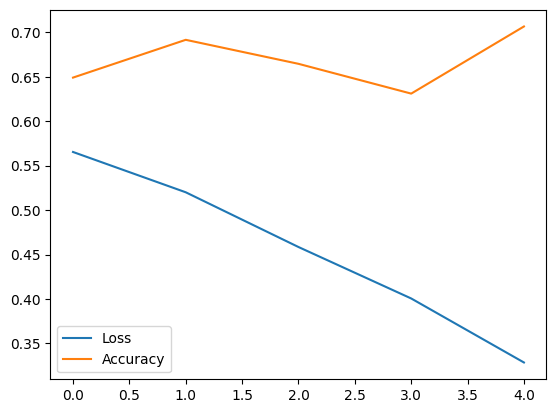

In [84]:
import matplotlib.pyplot as plt

history = {"loss": [], "acc": []}

for epoch in range(5):
    loss = train_model(model, train_loader, criterion, optimizer, device)
    acc = evaluate_model(model, test_loader, device)
    history["loss"].append(loss)
    history["acc"].append(acc)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Test Acc={acc:.4f}")

# 학습 곡선 시각화
plt.plot(history["loss"], label="Loss")
plt.plot(history["acc"], label="Accuracy")
plt.legend()
plt.show()


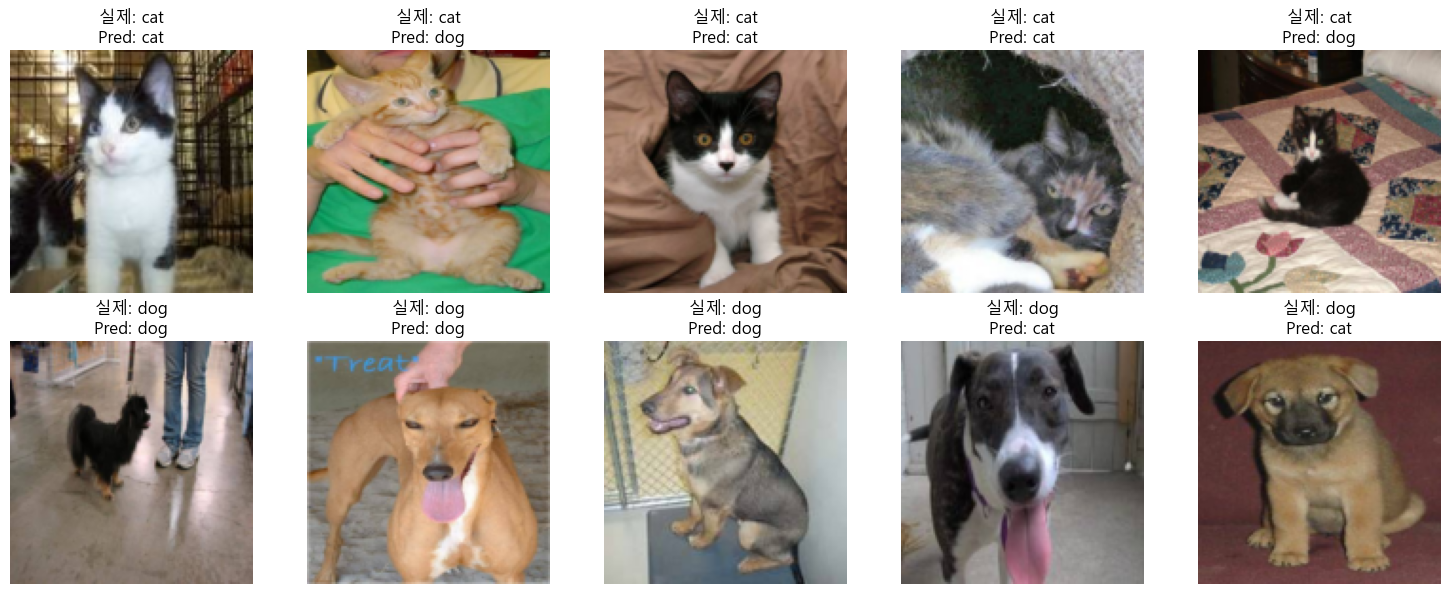

In [93]:
import matplotlib.pyplot as plt
import torch

classes = ["cat", "dog"]

# 모델 평가 모드
model.eval()

# 테스트 데이터 전체에서 인덱스 추출
labels_all = torch.tensor([label for _, label in test_ds])  # 전체 라벨
cat_indices = (labels_all == 0).nonzero(as_tuple=True)[0][:5]
dog_indices = (labels_all == 1).nonzero(as_tuple=True)[0][:5]
selected_indices = torch.cat([cat_indices, dog_indices])

# 이미지와 라벨 가져오기
images_to_show = torch.stack([test_ds[i][0] for i in selected_indices])
labels_to_show = torch.tensor([test_ds[i][1] for i in selected_indices])

# 모델 예측
with torch.no_grad():
    outputs = model(images_to_show.to(device))
    _, preds_to_show = torch.max(outputs, 1)
    preds_to_show = preds_to_show.cpu()

# 2행 5열 서브플롯
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = images_to_show[i].permute(1,2,0).numpy()
    ax.imshow(img)
    ax.set_title(f"실제: {classes[labels_to_show[i]]}\nPred: {classes[preds_to_show[i]]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [92]:
import matplotlib.pyplot as plt
# import matplotlib.pylab as plt
import matplotlib.font_manager as fm
%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac (AppleGothic 또는 AppleSDGothicNeo)
# plt.rcParams['font.family'] = 'NanumGothic' # Linux (NanumGothic 또는 다른 설치된 한글 폰트)

# plt.rcParams['axes.unicode_minus'] = False #glypy 8722: Axes에 - 표시 안되는 것